In [27]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'Experiment_GUET').exists():
            return p
    raise FileNotFoundError('未找到包含 Experiment_GUET 的项目根目录')


PROJECT_ROOT = find_project_root()
PIC_DIR = PROJECT_ROOT / 'Experiment_GUET' / 'pic'
OUT_DIR = PROJECT_ROOT / 'Experiment_GUET' / 'src' / '实验四' / 'results_strict'
OUT_DIR.mkdir(parents=True, exist_ok=True)


def read_gray(path: Path) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f'无法读取图像: {path}')
    return img


def normalize_u8(x: np.ndarray) -> np.ndarray:
    return cv2.normalize(x, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


def show_and_save(fig, name: str) -> None:
    fig.tight_layout()
    fig.savefig(OUT_DIR / name, dpi=150, bbox_inches='tight')
    plt.show()


def rect_kernel(n: int) -> np.ndarray:
    return cv2.getStructuringElement(cv2.MORPH_RECT, (n, n))


print(f'项目根目录: {PROJECT_ROOT}')
print(f'结果目录: {OUT_DIR}')

项目根目录: /home/ubuntu/codebase/yexijia/github_project/DIP
结果目录: /home/ubuntu/codebase/yexijia/github_project/DIP/Experiment_GUET/src/实验四/results_strict



实验要求思考：膨胀扩展的是高频/低频/亮部/暗部中的哪一类？腐蚀收缩的是哪一类？


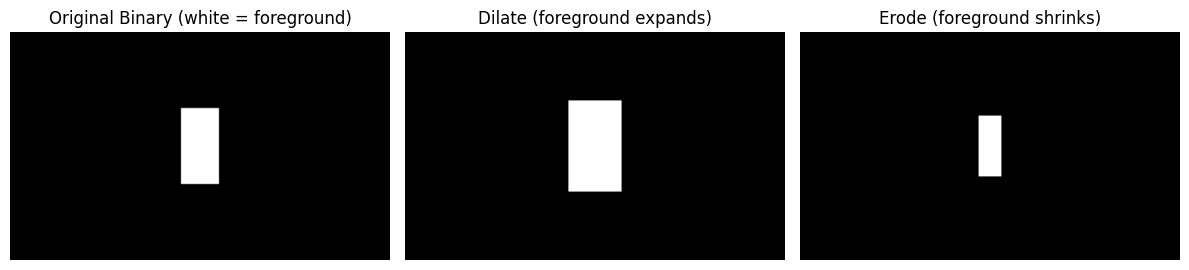

In [28]:

h, w = 120, 200
# 二值图：白色竖条前景（亮像素），黑色背景（暗像素）
bin_img = np.zeros((h, w), np.uint8)
bin_img[40:80, 90:110] = 255  # 竖条前景


k = rect_kernel(9)  # 9x9矩形核
d_bin = cv2.dilate(bin_img, k)  # 膨胀
e_bin = cv2.erode(bin_img, k)   # 腐蚀


fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(bin_img, cmap='gray')
ax[0].set_title('Original Binary (white = foreground)')
ax[1].imshow(d_bin, cmap='gray')
ax[1].set_title('Dilate (foreground expands)')
ax[2].imshow(e_bin, cmap='gray')
ax[2].set_title('Erode (foreground shrinks)')

for a in ax.ravel():
    a.axis('off')

plt.tight_layout()
plt.show()


使用**同类**方形全 1 结构元，仅改变边长，对比：

1. 膨胀随尺寸增大如何变化；
2. 腐蚀随尺寸增大如何变化。


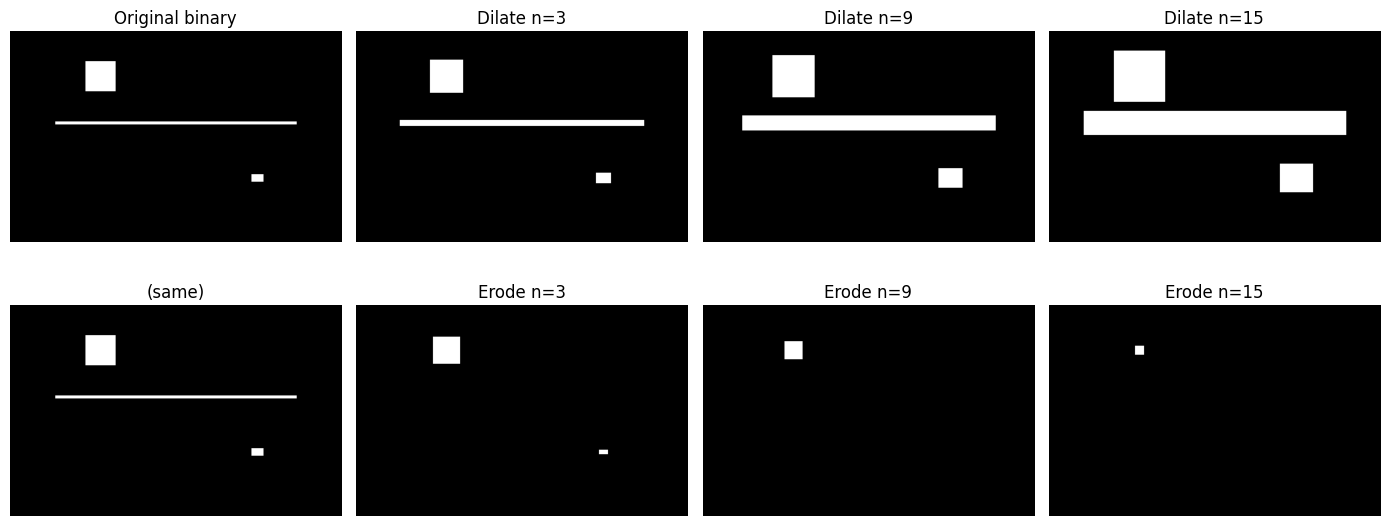

In [29]:
# 任务2：不同方形结构元尺寸
g = np.zeros((140, 220), np.uint8)
g[60:62, 30:190] = 255
g[20:40, 50:70] = 255
g[95:100, 160:168] = 255

sizes = (3, 9, 15)
fig, ax = plt.subplots(2, len(sizes) + 1, figsize=(14, 6))
ax[0, 0].imshow(g, cmap='gray')
ax[0, 0].set_title('Original binary')
ax[1, 0].imshow(g, cmap='gray')
ax[1, 0].set_title('(same)')
for j, n in enumerate(sizes, start=1):
    k = rect_kernel(n)
    ax[0, j].imshow(cv2.dilate(g, k), cmap='gray')
    ax[0, j].set_title(f'Dilate n={n}')
    ax[1, j].imshow(cv2.erode(g, k), cmap='gray')
    ax[1, j].set_title(f'Erode n={n}')
for a in ax.ravel():
    a.axis('off')
show_and_save(fig, 'task2_se_size_dilate_erode.png')

结构元尺寸对开运算、闭运算的影响

开运算 = 先腐蚀后膨胀；闭运算 = 先膨胀后腐蚀。比较同一方形结构元在 **不同边长** 下：

3. 开运算效果差异；
4. 闭运算效果差异。


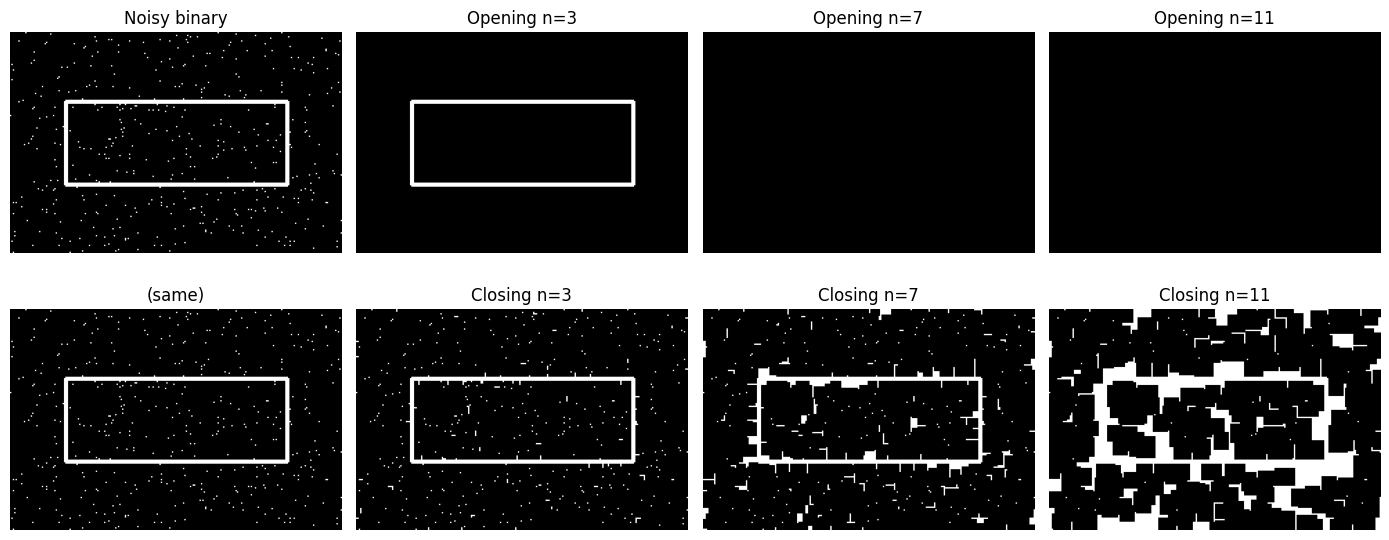

In [30]:

base = np.zeros((160, 240), np.uint8)
cv2.rectangle(base, (40, 50), (200, 110), 255, 2)
rng = np.random.default_rng(0)
salt = (rng.random(base.shape) < 0.012).astype(np.uint8) * 255
base = np.clip(base.astype(np.int16) + salt, 0, 255).astype(np.uint8)

sizes = (3, 7, 11)
fig, ax = plt.subplots(2, len(sizes) + 1, figsize=(14, 6))
ax[0, 0].imshow(base, cmap='gray')
ax[0, 0].set_title('Noisy binary')
ax[1, 0].imshow(base, cmap='gray')
ax[1, 0].set_title('(same)')
for j, n in enumerate(sizes, start=1):
    k = rect_kernel(n)
    op = cv2.morphologyEx(base, cv2.MORPH_OPEN, k)
    cl = cv2.morphologyEx(base, cv2.MORPH_CLOSE, k)
    ax[0, j].imshow(op, cmap='gray')
    ax[0, j].set_title(f'Opening n={n}')
    ax[1, j].imshow(cl, cmap='gray')
    ax[1, j].set_title(f'Closing n={n}')
for a in ax.ravel():
    a.axis('off')
show_and_save(fig, 'task3_open_close_se_size.png')

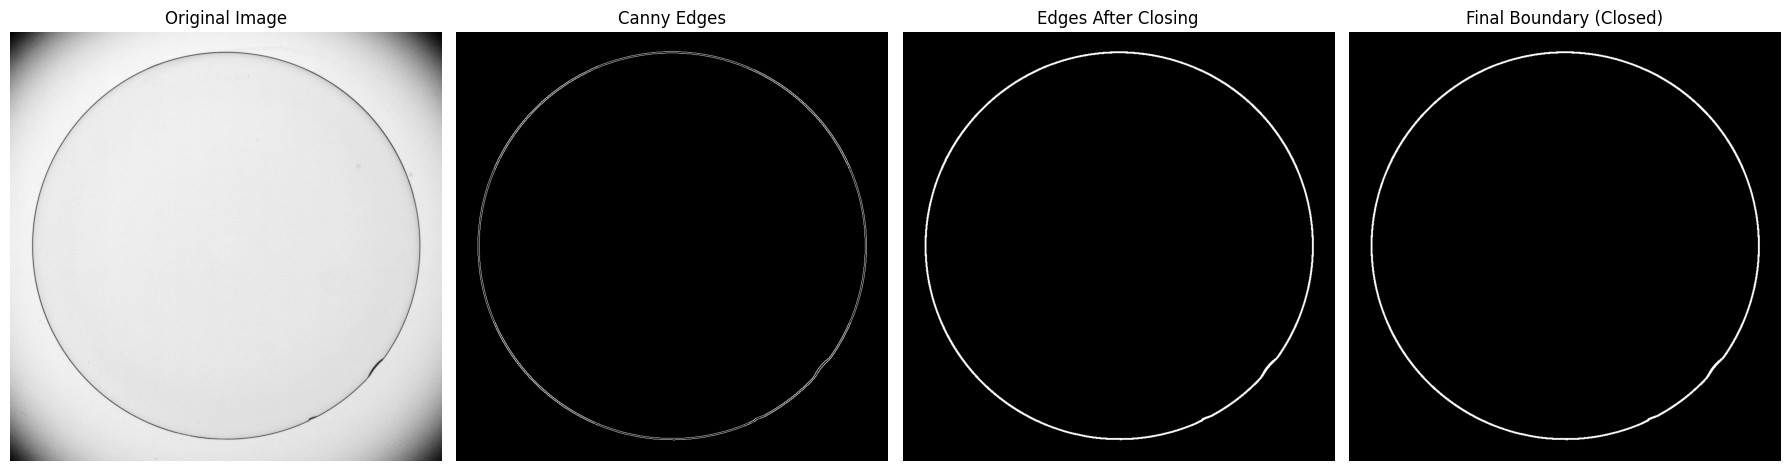

In [37]:

def show_image(ax, img, title):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')


lens = read_gray(PIC_DIR / 'Fig0342(a)(contact_lens_original).tif')
if lens is None:
    raise FileNotFoundError('未找到 Fig0342(a)(contact_lens_original).tif')

# 兼容灰度图/彩色图输入
if lens.ndim == 3:
    lens_gray = cv2.cvtColor(lens, cv2.COLOR_BGR2GRAY)
    result_overlay = lens.copy()
else:
    lens_gray = lens
    result_overlay = cv2.cvtColor(lens_gray, cv2.COLOR_GRAY2BGR)

# 预处理：轻度平滑，降低噪声对边缘检测的影响
lens_blur = cv2.GaussianBlur(lens_gray, (5, 5), 1.2)

# Canny 提取边缘
edges = cv2.Canny(lens_blur, 35, 90)

# 用形态学闭运算增强边缘连续性
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)

# 简化：闭运算后直接作为最终边界
boundary_only = edges_closed.copy()

# 直接叠加闭运算结果到原图（白色边缘）
result_overlay = cv2.cvtColor(lens_gray, cv2.COLOR_GRAY2BGR)
result_overlay[boundary_only > 0] = (255, 255, 255)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
show_image(axes[0], lens_gray, 'Original Image')
show_image(axes[1], edges, 'Canny Edges')
show_image(axes[2], edges_closed, 'Edges After Closing')
show_image(axes[3], boundary_only, 'Final Boundary (Closed)')
plt.tight_layout()
plt.show()




2. **形态学骨架**：迭代 `skel |= (img - morph_open(img))`，`img = erode(img)` 直至空（仅用 `erode` / `dilate` / `subtract` / `bitwise_or` 组合）。
3. **Zhang-Suen 细化**：经典二值细化（下面为纯 NumPy 实现，便于与形态学骨架并排对比）。

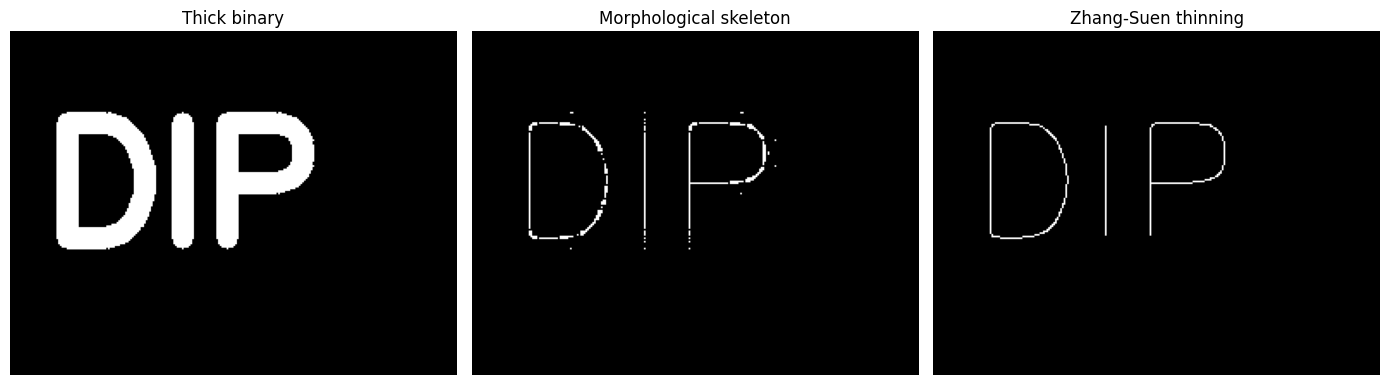

In [32]:
# 任务5：形态学骨架 vs Zhang-Suen 细化


def morphological_skeleton(bin_fg255: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Lantuéjoul 形态学骨架（前景 255）。"""
    img = (bin_fg255 > 0).astype(np.uint8) * 255
    skel = np.zeros_like(img)
    while True:
        opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
        temp = cv2.subtract(img, opened) # 原图减开运算结果
        skel = cv2.bitwise_or(skel, temp) # 叠加到骨架图里
        eroded = cv2.erode(img, kernel) # 腐蚀
        if cv2.countNonZero(eroded) == 0:
            break
        img = eroded
    return skel


def zhang_suen_thinning(bin_fg255: np.ndarray) -> np.ndarray:
    """Zhang-Suen thinning, foreground=1 in algorithm."""
    im = (bin_fg255 > 0).astype(np.uint8)
    def neighbors(y, x):
        p2, p3, p4, p5, p6, p7, p8, p9 = (
            im[y - 1, x],
            im[y - 1, x + 1],
            im[y, x + 1],
            im[y + 1, x + 1],
            im[y + 1, x],
            im[y + 1, x - 1],
            im[y, x - 1],
            im[y - 1, x - 1],
        )
        return p2, p3, p4, p5, p6, p7, p8, p9

    def transitions(p):
        n = p + (p[0],)
        return sum((n[i] == 0 and n[i + 1] == 1) for i in range(8))

    h, w = im.shape
    im = im.copy()
    im[[0, h - 1], :] = 0
    im[:, [0, w - 1]] = 0
    changed = True
    while changed:
        changed = False
        m1 = []
        for y in range(1, h - 1):
            for x in range(1, w - 1):
                if im[y, x] != 1:
                    continue
                p2, p3, p4, p5, p6, p7, p8, p9 = neighbors(y, x)
                arr = (p2, p3, p4, p5, p6, p7, p8, p9)
                B = sum(arr)
                if B < 2 or B > 6:
                    continue
                if transitions(arr) != 1:
                    continue
                if p2 * p4 * p6 != 0:
                    continue
                if p4 * p6 * p8 != 0:
                    continue
                m1.append((y, x))
        for y, x in m1:
            im[y, x] = 0
            changed = True
        m2 = []
        for y in range(1, h - 1):
            for x in range(1, w - 1):
                if im[y, x] != 1:
                    continue
                p2, p3, p4, p5, p6, p7, p8, p9 = neighbors(y, x)
                arr = (p2, p3, p4, p5, p6, p7, p8, p9)
                B = sum(arr)
                if B < 2 or B > 6:
                    continue
                if transitions(arr) != 1:
                    continue
                if p2 * p4 * p8 != 0:
                    continue
                if p2 * p6 * p8 != 0:
                    continue
                m2.append((y, x))
        for y, x in m2:
            im[y, x] = 0
            changed = True
    return (im * 255).astype(np.uint8)


stroke = np.zeros((200, 260), np.uint8)
cv2.putText(stroke, 'DIP', (20, 120), cv2.FONT_HERSHEY_SIMPLEX, 3.2, 255, 12)
_, stroke_bw = cv2.threshold(stroke, 127, 255, cv2.THRESH_BINARY)

k3 = rect_kernel(3)
sk = morphological_skeleton(stroke_bw, k3)
th = zhang_suen_thinning(stroke_bw)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(stroke_bw, cmap='gray')
ax[0].set_title('Thick binary')
ax[1].imshow(sk, cmap='gray')
ax[1].set_title('Morphological skeleton')
ax[2].imshow(th, cmap='gray')
ax[2].set_title('Zhang-Suen thinning')
for a in ax:
    a.axis('off')
show_and_save(fig, 'task5_thinning_vs_skeleton.png')

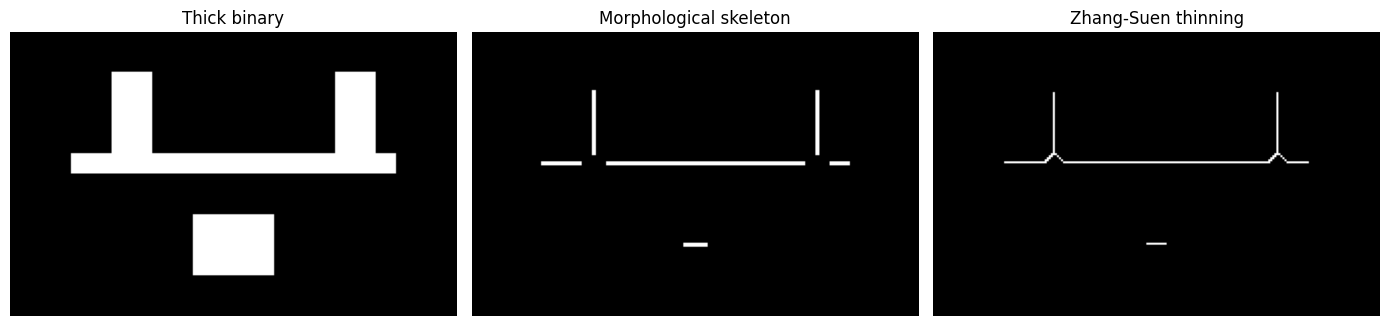

In [ ]:

g = np.zeros((140, 220), np.uint8)
g[60:70, 30:190]   = 255   # 桌子横梁
g[20:60, 50:70]     = 255   # 左边桌腿
g[20:60, 160:180]   = 255   # 右边桌腿
g[90:120, 90:130]   = 255   # 下方方块

# 二值化（确保干净）
_, stroke_bw = cv2.threshold(g, 127, 255, cv2.THRESH_BINARY)


k3 = rect_kernel(3)
sk = morphological_skeleton(stroke_bw, k3)    # 形态学骨架
th = zhang_suen_thinning(stroke_bw)           # Zhang-Suen 细化


fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(stroke_bw, cmap='gray')
ax[0].set_title('Thick binary')
ax[1].imshow(sk, cmap='gray')
ax[1].set_title('Morphological skeleton')
ax[2].imshow(th, cmap='gray')
ax[2].set_title('Zhang-Suen thinning')

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()


